#  Video Deepfake Detection — ResNeXt101 Fine-tuned + MTCNN + FF++ C23


**Pipeline :**
1. Install and Import
2. Download Dataset
3. Explore Dataset
4. MTCNN Face Extraction (aligned, 224x224)
5. Save Extracted Face on Drive
6. DataLoaders with Augmentation
7. ResNeXt101 with partial unfreezing (layer3 + layer4)
8. Train with Cosine LR + Early Stopping
9. Evaluate on held-out test set
10. Save Model
11. Predict on new video


## Step 1: Install Required Libraries

In [20]:
print(" Installing required libraries...")

!pip install -q facenet-pytorch==2.5.3

print(" Libraries installed successfully!")

 Installing required libraries...
 Libraries installed successfully!


## Step 2: Import All Modules

In [21]:
print(" Importing all required modules...")

import os
import random
import glob
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms

from torchvision import models
from torch.utils.data import Dataset, DataLoader

from facenet_pytorch import MTCNN

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tqdm import tqdm
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from torch.cuda.amp import autocast, GradScaler

import warnings
warnings.filterwarnings('ignore')

print(" All modules imported successfully!")

 Importing all required modules...
 All modules imported successfully!


#Drive Mount

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#SAVE DIRECTORY

In [23]:
SAVE_DIR = "/content/drive/MyDrive/deepfake_video"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Save directory ready!")

Save directory ready!


## Step 3: Setup Kaggle API and Download FF++ C23 Dataset
> If extracted faces are already saved on Drive then jump to Step 10.


In [8]:
print(" Configuring Kaggle API credentials...")
from google.colab import files

files.upload()  # Upload your kaggle.json here
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print(" Kaggle credentials configured!")

print("\n Downloading FF++ C23 dataset (large - may take 10-30 min)...")
!kaggle datasets download -d xdxd003/ff-c23
print(" Download complete! Unzipping...")
!unzip -q ff-c23.zip -d ff_c23
print(" Dataset ready!")

 Configuring Kaggle API credentials...


Saving kaggle.json to kaggle.json
 Kaggle credentials configured!

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [02:36<00:00, 114MB/s]

 Download complete! Unzipping...
 Dataset ready!


## Step 4: Explore and Verify Dataset Structure

In [9]:
print(" Scanning FF++ C23 dataset structure...")

BASE = "ff_c23"

REAL_DIR = os.path.join(BASE, "FaceForensics++_C23", "original")

FAKE_DIRS = {
    "Deepfakes"     : os.path.join(BASE, "FaceForensics++_C23", "Deepfakes"      ),
    "Face2Face"     : os.path.join(BASE, "FaceForensics++_C23", "Face2Face"      ),
    "FaceSwap"      : os.path.join(BASE, "FaceForensics++_C23", "FaceSwap"      ),
    "NeuralTextures": os.path.join(BASE, "FaceForensics++_C23", "NeuralTextures" ),
}

def count_videos(path):
    if not os.path.exists(path):
        return 0
    return len([f for f in os.listdir(path)
                if f.lower().endswith(('.mp4', '.avi', '.mov'))])

real_count = count_videos(REAL_DIR)
print(f" REAL videos : {real_count}")

total_fake = 0
for method, path in FAKE_DIRS.items():
    cnt = count_videos(path)
    total_fake += cnt
    print(f" FAKE [{method:15s}]: {cnt}")

print(f"\n Total REAL  : {real_count}")
print(f" Total FAKE  : {total_fake}")
print(f" Grand Total : {real_count + total_fake}")
print(" Dataset verified!")

 Scanning FF++ C23 dataset structure...
 REAL videos : 1000
 FAKE [Deepfakes      ]: 1000
 FAKE [Face2Face      ]: 1000
 FAKE [FaceSwap       ]: 1000
 FAKE [NeuralTextures ]: 1000

 Total REAL  : 1000
 Total FAKE  : 4000
 Grand Total : 5000
 Dataset verified!


## Step 5: Load MTCNN Face Detector


In [24]:
print(" Setting up compute device and MTCNN face detector...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")
if device.type == 'cuda':
    print(f" GPU: {torch.cuda.get_device_name(0)}")

# MTCNN: detects + aligns face in one step, outputs 224x224 cropped face
mtcnn = MTCNN(
    image_size=224,      # matches ResNeXt101 pretrained input exactly
    margin=20,           # extra margin around detected face
    min_face_size=40,    # ignore very small faces (noise)
    keep_all=False,      # keep only largest/most confident face per frame
    device=device,
    post_process=False   # return 0-255 uint8 instead of normalized tensor
)

print(" MTCNN loaded! (image_size=224, margin=20, min_face=40px)")
print(" MTCNN aligns faces to canonical pose — crucial for artifact detection")

 Setting up compute device and MTCNN face detector...
 Device: cpu
 MTCNN loaded! (image_size=224, margin=20, min_face=40px)
 MTCNN aligns faces to canonical pose — crucial for artifact detection


## Step 6: Face Extraction from Video


In [25]:
print(" Defining BATCH face extraction")

# Batch MTCNN — processes multiple frames at once on GPU
mtcnn = MTCNN(
    image_size=224,
    margin=20,
    min_face_size=40,
    keep_all=False,
    device=device,
    post_process=False
)

def extract_faces_from_video(video_path, frame_count=25,
                              output_size=(224, 224), batch_size=64):

    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total == 0:
        cap.release()
        return []

    # Uniform sampling across full video duration
    indices = np.linspace(0, total - 1, frame_count, dtype=int)

    # Read all frames first
    frames_pil = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames_pil.append(Image.fromarray(rgb))
    cap.release()

    if len(frames_pil) == 0:
        return []

    # Process in batches on GPU
    faces = []
    for i in range(0, len(frames_pil), batch_size):
        batch = frames_pil[i : i + batch_size]
        try:
            face_tensors = mtcnn(batch)   # entire batch runs on GPU at once
            if face_tensors is None:
                continue
            # mtcnn returns a single tensor or list depending on batch size
            if not isinstance(face_tensors, list):
                face_tensors = [face_tensors]
            for ft in face_tensors:
                if ft is None:
                    continue
                face_np = ft.permute(1, 2, 0).byte().cpu().numpy()
                face_pil = Image.fromarray(face_np).resize(output_size)
                faces.append(face_pil)
        except Exception:
            continue

    return faces


print(" batch_size=64 frames processed simultaneously on GPU")


 Defining BATCH face extraction
 batch_size=64 frames processed simultaneously on GPU


## Step 7: Extract Faces and Build Dataset


In [ ]:
print(" Starting batched face extraction from all videos...")
print(" This will be significantly faster than sequential extraction.")

FRAME_COUNT = 16
MAX_VIDEOS = 400      # cap per class
TMP_DIR = "./faces_tmp"
os.makedirs(TMP_DIR, exist_ok=True)

filepaths, labels = [], []

# REAL videos
real_vids = [f for f in os.listdir(REAL_DIR)
             if f.lower().endswith(('.mp4', '.avi', '.mov'))][:MAX_VIDEOS]
print(f"\n Processing {len(real_vids)} REAL videos...")

for vf in tqdm(real_vids, desc="REAL"):
    faces = extract_faces_from_video(os.path.join(REAL_DIR, vf), frame_count=FRAME_COUNT)
    for idx, face in enumerate(faces):
        out_path = os.path.join(TMP_DIR, f"0_{vf}_{idx}.jpg")
        face.save(out_path)
        filepaths.append(out_path)
        labels.append(0)  # 0 = REAL

print(f" REAL face crops saved: {labels.count(0)}")

# FAKE videos — all 4 manipulation methods
max_per_method = MAX_VIDEOS // len(FAKE_DIRS)

for method, fake_dir in FAKE_DIRS.items():
    if not os.path.exists(fake_dir):
        print(f" Skipping {method} — directory not found")
        continue

    fake_vids = [f for f in os.listdir(fake_dir)
                 if f.lower().endswith(('.mp4', '.avi', '.mov'))][:max_per_method]
    print(f"\n Processing {len(fake_vids)} FAKE videos [{method}]...")

    for vf in tqdm(fake_vids, desc=method):
        faces = extract_faces_from_video(os.path.join(fake_dir, vf), frame_count=FRAME_COUNT)
        for idx, face in enumerate(faces):
            out_path = os.path.join(TMP_DIR, f"1_{method}_{vf}_{idx}.jpg")
            face.save(out_path)
            filepaths.append(out_path)
            labels.append(1)  # 1 = FAKE

print(f"\n Extraction complete!")
print(f"   REAL face crops : {labels.count(0)}")
print(f"   FAKE face crops : {labels.count(1)}")
print(f"   Total           : {len(filepaths)}")

 Starting batched face extraction from all videos...
 This will be significantly faster than sequential extraction.

 Processing 400 REAL videos...


REAL: 100%|██████████| 400/400 [41:37<00:00,  6.24s/it]


 REAL face crops saved: 6400

 Processing 100 FAKE videos [Deepfakes]...


Deepfakes: 100%|██████████| 100/100 [09:34<00:00,  5.75s/it]



 Processing 100 FAKE videos [Face2Face]...


...


 Processing 100 FAKE videos [FaceSwap]...


FaceSwap: 100%|██████████| 100/100 [09:32<00:00,  5.73s/it]



 Processing 100 FAKE videos [NeuralTextures]...


NeuralTextures: 100%|██████████| 100/100 [09:08<00:00,  5.49s/it]


 Extraction complete!
   REAL face crops : 6400
   FAKE face crops : 6400
   Total           : 12800


## Step 8: Save Extracted Face on Drive


In [ ]:
# Zip the faces and push them to Drive so they survive the session disconnect
!zip -r -q /content/deepfake_faces.zip /content/faces_tmp
#!cp /content/deepfake_faces.zip /content/drive/MyDrive/
!cp /content/deepfake_faces.zip {SAVE_DIR}/
print("saved on drive")

saved on drive


## Step 9: Sample Visualization — Real vs Fake Face Crops
> Execute the next 2 cell if extracted faces are already saved on Drive.

In [6]:
import os

SAVE_DIR = "/content/drive/MyDrive/deepfake_video"

zip_path = os.path.join(
    SAVE_DIR,
    "deepfake_faces.zip"
)

print(zip_path)

print("Exists:", os.path.exists(zip_path))

/content/drive/MyDrive/deepfake_video/deepfake_faces.zip
Exists: True


In [12]:
print("Pulling faces from permanent storage into Colab memory...")

zip_path = os.path.join(
    SAVE_DIR,
    "deepfake_faces.zip"
)

# Copy ZIP from Drive
!cp "$zip_path" /content/

print("Unzipping directly into Colab memory...")

# Unzip
!unzip -q /content/deepfake_faces.zip -d /content/

# If nested folder exists, move faces_tmp properly
if os.path.exists("/content/content/faces_tmp"):

    print("Fixing nested folder structure...")

    if not os.path.exists("/content/faces_tmp"):

        !mv /content/content/faces_tmp /content/

    !rm -rf /content/content

print("Face dataset restored successfully!")

# Final verification
print(
    "faces_tmp exists:",
    os.path.exists("/content/faces_tmp")
)

Pulling faces from permanent storage into Colab memory...
Unzipping directly into Colab memory...
Fixing nested folder structure...
Face dataset restored successfully!
faces_tmp exists: True


 Displaying sample extracted face crops...
         -> Step 7 skipped. Scanning local directory for unzipped faces...


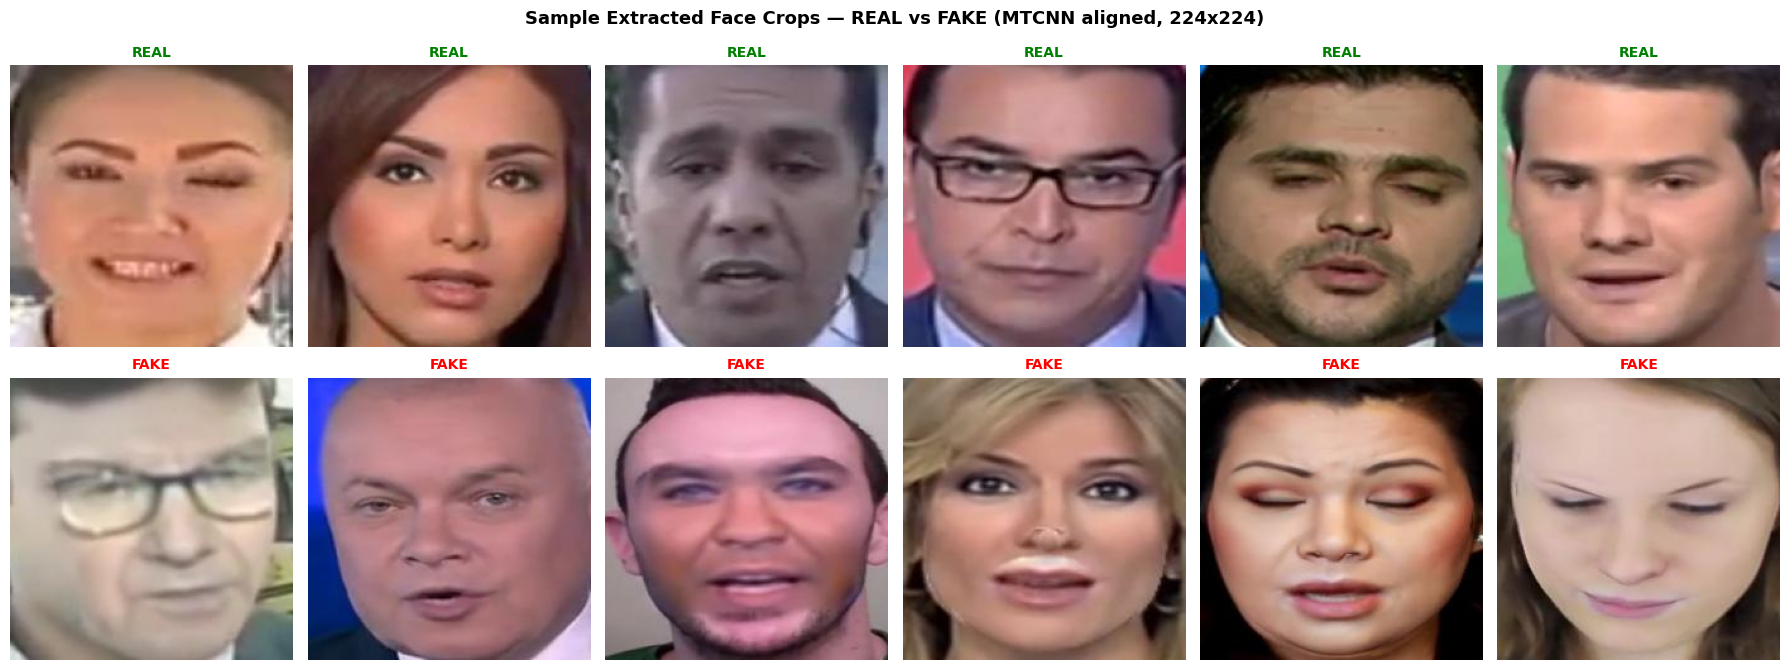


 Sample images displayed!


In [13]:
import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image

print(" Displaying sample extracted face crops...")

# 1. Check if we ran Step 7 (variables exist in memory)
if 'filepaths' in globals() and 'labels' in globals():
    print("         -> Using in-memory file paths from Step 7...")
    real_paths = [p for p, l in zip(filepaths, labels) if l == 0]
    fake_paths = [p for p, l in zip(filepaths, labels) if l == 1]

# 2. If skipped, scan the directory instead
else:
    print("         -> Step 7 skipped. Scanning local directory for unzipped faces...")
    TMP_DIR = "/content/faces_tmp" # Ensure this matches your unzip destination
    all_extracted_faces = glob.glob(os.path.join(TMP_DIR, "*.jpg"))

    # Sort based on your naming convention (0_ for REAL, 1_ for FAKE)
    real_paths = [p for p in all_extracted_faces if os.path.basename(p).startswith('0_')]
    fake_paths = [p for p in all_extracted_faces if os.path.basename(p).startswith('1_')]

# 3. Proceed with your original visualization code safely
if not real_paths or not fake_paths:
    print(f"❌ ERROR: Could not find images! Make sure they are unzipped to {TMP_DIR}.")
else:
    fig, axes = plt.subplots(2, 6, figsize=(18, 7))
    fig.suptitle('Sample Extracted Face Crops — REAL vs FAKE (MTCNN aligned, 224x224)',
                 fontsize=13, fontweight='bold')

    for i in range(6):
        # Safeguard just in case you have fewer than 6 images
        if len(real_paths) > 0:
            img = Image.open(random.choice(real_paths))
            axes[0][i].imshow(img)
            axes[0][i].set_title('REAL', color='green', fontsize=10, fontweight='bold')
            axes[0][i].axis('off')

        if len(fake_paths) > 0:
            img = Image.open(random.choice(fake_paths))
            axes[1][i].imshow(img)
            axes[1][i].set_title('FAKE', color='red', fontsize=10, fontweight='bold')
            axes[1][i].axis('off')

    plt.tight_layout()
    plt.show()
    print("\n Sample images displayed!")

## Step 10: Train / Val / Test Split (70 / 15 / 15)


In [14]:
from sklearn.model_selection import train_test_split

print(" Creating train / val / test splits (70 / 15 / 15)...")

# 1. Safely rebuild filepaths and labels if Step 7 was skipped
if 'filepaths' not in globals() or 'labels' not in globals():
    print("         -> Step 8 skipped. Rebuilding lists from Step 9...")
    # Combine the paths we found in Step 9
    filepaths = real_paths + fake_paths
    # Generate matching labels: 0 for REAL, 1 for FAKE
    labels = [0] * len(real_paths) + [1] * len(fake_paths)

# 2. Perform the split
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f" Split complete!")
print(f"   Train : {len(X_train)} samples")
print(f"   Val   : {len(X_val)} samples")
print(f"   Test  : {len(X_test)} samples (held-out, not used until final eval)")

 Creating train / val / test splits (70 / 15 / 15)...
         -> Step 8 skipped. Rebuilding lists from Step 9...
 Split complete!
   Train : 8960 samples
   Val   : 1920 samples
   Test  : 1920 samples (held-out, not used until final eval)


## Step 11: Dataset Class and DataLoaders with Augmentation


In [26]:
print(" Defining Dataset class and transforms...")
print("   Train: augmented (Flip + ColorJitter + Rotation)")
print("   Val/Test: clean evaluation transform")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


class FaceFrameDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


BATCH_SIZE = 16

train_ds = FaceFrameDataset(X_train, y_train, transform=train_transform)
val_ds   = FaceFrameDataset(X_val,   y_val,   transform=eval_transform)
test_ds  = FaceFrameDataset(X_test,  y_test,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

# Clean train loader for stable feature extraction
clean_train_ds = FaceFrameDataset(
    X_train,
    y_train,
    transform=eval_transform
)

clean_train_loader = DataLoader(
    clean_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(" Clean train loader created for fusion embeddings")

print(f" Datasets and DataLoaders ready!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

 Defining Dataset class and transforms...
   Train: augmented (Flip + ColorJitter + Rotation)
   Val/Test: clean evaluation transform


NameError: name 'X_train' is not defined

## Step 12: Load ResNeXt101


In [28]:
print(" Loading ResNeXt101...")

model = models.resnext101_32x8d(weights='DEFAULT')

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer3 and layer4
for name, param in model.named_parameters():
    if 'layer3' in name or 'layer4' in name:
        param.requires_grad = True

# Replace FC head
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 2)
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

torch.backends.cudnn.benchmark = True

trainable = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total = sum(p.numel() for p in model.parameters())

print(f"\nModel ready!")
print(f"Trainable params: {trainable:,}")
print(f"Total params: {total:,}")

 Loading ResNeXt101...

Model ready!
Trainable params: 84,957,698
Total params: 87,793,474


## Step 13: Training Setup


In [17]:
print(" Configuring loss, optimizer and LR scheduler...")

criterion = nn.CrossEntropyLoss()

backbone_params = [
    p for n, p in model.named_parameters()
    if ('layer3' in n or 'layer4' in n) and p.requires_grad
]

head_params = list(model.fc.parameters())

optimizer = optim.Adam([
    {'params': head_params,     'lr': 1e-4},
    {'params': backbone_params, 'lr': 1e-5},
])

EPOCHS = 10

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-7
)

# Mixed precision scaler
scaler = GradScaler()

print(f" Training configuration ready!")
print(f"   FC head LR     : 1e-4")
print(f"   Backbone LR    : 1e-5 (10x lower than head)")
print(f"   LR Scheduler   : CosineAnnealingLR (T_max={EPOCHS})")
print(f"   Epochs         : {EPOCHS}")
print(f"   Early stopping : patience = 5 epochs")

 Configuring loss, optimizer and LR scheduler...
 Training configuration ready!
   FC head LR     : 1e-4
   Backbone LR    : 1e-5 (10x lower than head)
   LR Scheduler   : CosineAnnealingLR (T_max=10)
   Epochs         : 10
   Early stopping : patience = 5 epochs


In [18]:
RESUME = False
START_EPOCH = 1
if RESUME:
    checkpoint = torch.load(
        os.path.join(SAVE_DIR, "checkpoint_epoch_5.pth"),
        map_location=device
    )

    model.load_state_dict(checkpoint['model_state_dict'])

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    START_EPOCH = checkpoint['epoch'] + 1

    print(f"Resuming from epoch {START_EPOCH}")

## Step 14: Training Loop with Early Stopping

In [19]:
print(" Starting training...\n")

PATIENCE      = 5
best_val_loss = float('inf')
patience_ctr  = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(START_EPOCH, EPOCHS + 1):

    # =========================
    # TRAINING PHASE
    # =========================
    model.train()

    train_loss = 0.0
    train_correct = 0

    for imgs, lbls in tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]",
        leave=False
    ):

        imgs = imgs.to(device)
        lbls = lbls.to(device)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass
        with autocast():

            outputs = model(imgs)

            loss = criterion(outputs, lbls)

        # Mixed precision backward pass
        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        train_loss += loss.item() * imgs.size(0)

        train_correct += (
            outputs.argmax(1) == lbls
        ).sum().item()

    # =========================
    # VALIDATION PHASE
    # =========================
    model.eval()

    val_loss = 0.0
    val_correct = 0

    with torch.no_grad():

        for imgs, lbls in val_loader:

            imgs = imgs.to(device)
            lbls = lbls.to(device)

            with autocast():

                out = model(imgs)

                loss_val = criterion(out, lbls)

            val_loss += (
                loss_val.item()
                * imgs.size(0)
            )

            val_correct += (
                out.argmax(1) == lbls
            ).sum().item()

    # =========================
    # METRICS
    # =========================
    t_loss = train_loss / len(train_ds)
    t_acc  = train_correct / len(train_ds)

    v_loss = val_loss / len(val_ds)
    v_acc  = val_correct / len(val_ds)

    lr_now = optimizer.param_groups[0]['lr']

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)

    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
        f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f} | "
        f"LR: {lr_now:.2e}"
    )

    scheduler.step()

    # =========================
    # SAVE BEST MODEL
    # =========================
    if v_loss < best_val_loss:

        best_val_loss = v_loss
        patience_ctr  = 0

        torch.save(
            model.state_dict(),
            os.path.join(
                SAVE_DIR,
                "best_resnext101_deepfake.pth"
            )
        )

        print(
            f" Best model saved "
            f"(val_loss={v_loss:.4f})"
        )

    else:

        patience_ctr += 1

        if patience_ctr >= PATIENCE:

            print(
                f"\n Early stopping "
                f"triggered after {epoch} epochs."
            )

            break

    # =========================
    # SAVE CHECKPOINT
    # =========================
    if epoch % 2 == 0:

        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            },

            os.path.join(
                SAVE_DIR,
                f"checkpoint_epoch_{epoch}.pth"
            )
        )

        print(f" Checkpoint saved for epoch {epoch}")

print("\n Training complete!")

 Starting training...



Epoch 01/10 | Train Loss: 0.6235 Acc: 0.6518 | Val Loss: 0.5174 Acc: 0.7448 | LR: 1.00e-04
 Best model saved (val_loss=0.5174)


Epoch 02/10 | Train Loss: 0.4511 Acc: 0.7844 | Val Loss: 0.3592 Acc: 0.8458 | LR: 9.76e-05
 Best model saved (val_loss=0.3592)
 Checkpoint saved for epoch 2


Epoch 03/10 | Train Loss: 0.3544 Acc: 0.8462 | Val Loss: 0.2780 Acc: 0.8839 | LR: 9.05e-05
 Best model saved (val_loss=0.2780)


Epoch 04/10 | Train Loss: 0.2758 Acc: 0.8855 | Val Loss: 0.2279 Acc: 0.9068 | LR: 7.94e-05
 Best model saved (val_loss=0.2279)
 Checkpoint saved for epoch 4


...

Epoch 06/10 | Train Loss: 0.2060 Acc: 0.9160 | Val Loss: 0.1632 Acc: 0.9344 | LR: 5.01e-05
 Best model saved (val_loss=0.1632)
 Checkpoint saved for epoch 6


Epoch 07/10 | Train Loss: 0.1809 Acc: 0.9278 | Val Loss: 0.1607 Acc: 0.9359 | LR: 3.46e-05
 Best model saved (val_loss=0.1607)


Epoch 08/10 | Train Loss: 0.1761 Acc: 0.9297 | Val Loss: 0.1404 Acc: 0.9411 | LR: 2.07e-05
 Best model saved (val_loss=0.1404)
 Checkpoint saved for epoch 8


Epoch 09/10 | Train Loss: 0.1717 Acc: 0.9331 | Val Loss: 0.1473 Acc: 0.9406 | LR: 9.64e-06


Epoch 10/10 | Train Loss: 0.1718 Acc: 0.9307 | Val Loss: 0.1517 Acc: 0.9370 | LR: 2.54e-06
 Checkpoint saved for epoch 10

 Training complete!


## Step 15: Plot Training History

 Plotting training history... 



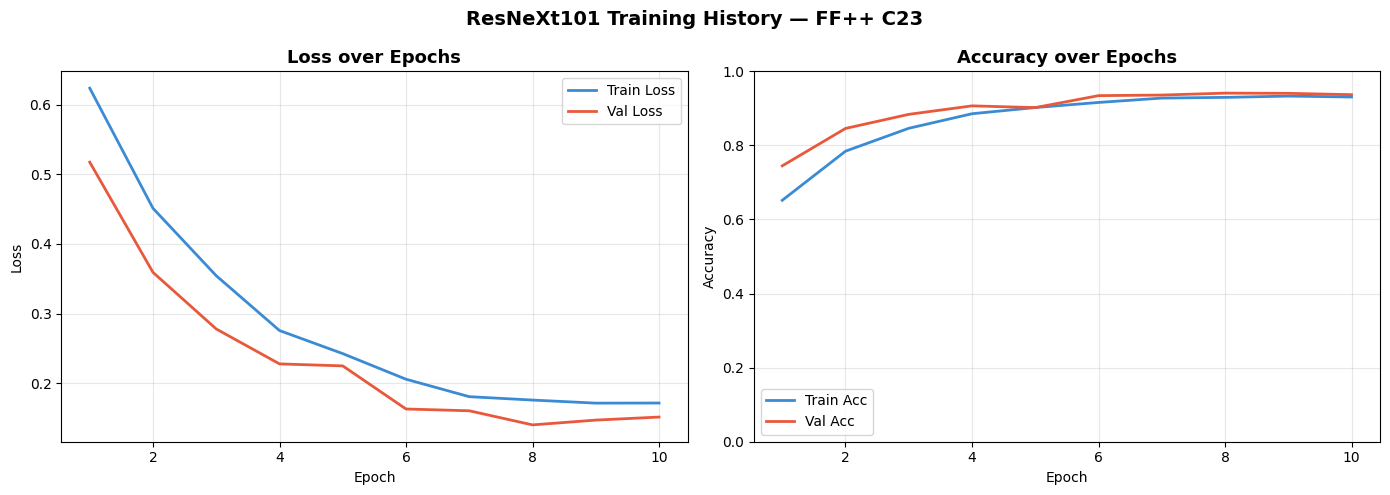


 Training history plotted!


In [20]:
print(" Plotting training history... \n")

epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='#3B8BD4', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='#E8593C', linewidth=2)
axes[0].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', color='#3B8BD4', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   color='#E8593C', linewidth=2)
axes[1].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNeXt101 Training History — FF++ C23', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(
        SAVE_DIR,
        'training_history.png'
    ),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("\n Training history plotted!")

## Step 16: Final Evaluation on Held-Out Test Set


 Loading best model and running final evaluation on test set...
 Feature extractor ready!


Extracting Train Features: 100%|██████████| 560/560 [02:19<00:00,  4.00it/s]



 Applying PCA for fusion compatibility...
 PCA complete!
Train shape: (8960, 128)
Test shape : (1920, 128)

 Fusion files saved!

  Test Accuracy : 93.02%

Classification Report:
              precision    recall  f1-score   support

        REAL       0.93      0.93      0.93       960
        FAKE       0.93      0.93      0.93       960

    accuracy                           0.93      1920
   macro avg       0.93      0.93      0.93      1920
weighted avg       0.93      0.93      0.93      1920



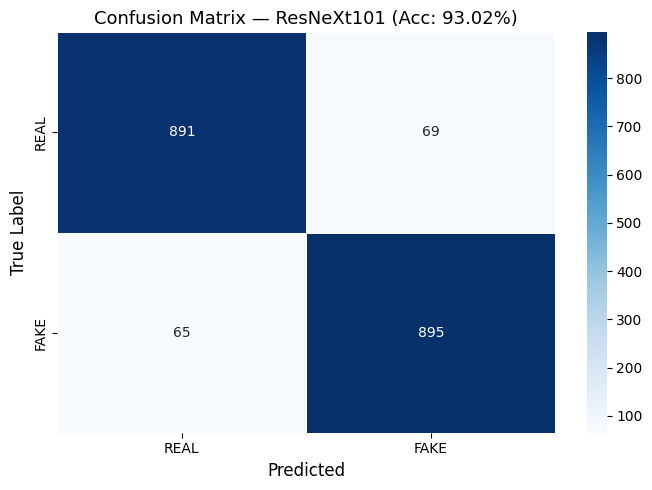


 Evaluation complete!


In [21]:
print(" Loading best model and running final evaluation on test set...")

# =========================================================
# LOAD BEST MODEL
# =========================================================

model.load_state_dict(
    torch.load(
        os.path.join(
            SAVE_DIR,
            "best_resnext101_deepfake.pth"
        ),
        map_location=device
    )
)

model.eval()

# =========================================================
# FEATURE EXTRACTOR
# =========================================================

class FeatureExtractor(nn.Module):

    def __init__(self, model):

        super().__init__()

        self.features = nn.Sequential(
            *list(model.children())[:-1]
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, 1)

        return x

extractor = FeatureExtractor(model).to(device)

extractor.eval()

print(" Feature extractor ready!")

# =========================================================
# EVALUATION
# =========================================================

all_preds = []
all_true  = []

train_features = []
train_labels   = []

test_features = []
test_labels   = []

# ---------------------------
# TEST EVALUATION
# ---------------------------

with torch.no_grad():

    for imgs, lbls in tqdm(
        test_loader,
        desc="Evaluating"
    ):

        imgs = imgs.to(device)

        # Classification
        out = model(imgs)

        preds = out.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_true.extend(lbls.numpy())

        # Feature extraction
        feats = extractor(imgs)

        feats = feats.detach().cpu().numpy()

        test_features.extend(feats)

        test_labels.extend(lbls.numpy())

# ---------------------------
# TRAIN FEATURE EXTRACTION
# ---------------------------

with torch.no_grad():

    for imgs, lbls in tqdm(
        clean_train_loader,
        desc="Extracting Train Features"
    ):

        imgs = imgs.to(device)

        feats = extractor(imgs)

        feats = feats.detach().cpu().numpy()

        train_features.extend(feats)

        train_labels.extend(lbls.numpy())

# =========================================================
# CONVERT TO NUMPY
# =========================================================

train_features = np.array(
    train_features,
    dtype=np.float32
)

test_features = np.array(
    test_features,
    dtype=np.float32
)

train_labels = np.array(train_labels)
test_labels  = np.array(test_labels)

# =========================================================
# PCA → 128 DIMENSIONS
# =========================================================

print("\n Applying PCA for fusion compatibility...")

from sklearn.decomposition import IncrementalPCA
import joblib

pca = IncrementalPCA(
    n_components=128,
    batch_size=512
)

train_features_pca = pca.fit_transform(
    train_features
)

test_features_pca = pca.transform(
    test_features
)

print(" PCA complete!")

print(f"Train shape: {train_features_pca.shape}")
print(f"Test shape : {test_features_pca.shape}")

# =========================================================
# SAVE FUSION FILES
# =========================================================

np.save(
    os.path.join(
        SAVE_DIR,
        "video_vectors_train.npy"
    ),
    train_features_pca
)

np.save(
    os.path.join(
        SAVE_DIR,
        "video_vectors_test.npy"
    ),
    test_features_pca
)

np.save(
    os.path.join(
        SAVE_DIR,
        "video_labels_train.npy"
    ),
    train_labels
)

np.save(
    os.path.join(
        SAVE_DIR,
        "video_labels_test.npy"
    ),
    test_labels
)

joblib.dump(
    pca,
    os.path.join(
        SAVE_DIR,
        "video_pca.pkl"
    )
)

print("\n Fusion files saved!")

# =========================================================
# CLASSIFICATION METRICS
# =========================================================

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

acc = accuracy_score(
    all_true,
    all_preds
)

print(f"\n{'='*55}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"{'='*55}")

print("\nClassification Report:")

print(
    classification_report(
        all_true,
        all_preds,
        target_names=['REAL', 'FAKE']
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    all_true,
    all_preds
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['REAL', 'FAKE'],
    yticklabels=['REAL', 'FAKE'],
    linewidths=0.5
)

plt.xlabel('Predicted', fontsize=12)

plt.ylabel('True Label', fontsize=12)

plt.title(
    f'Confusion Matrix — ResNeXt101 '
    f'(Acc: {acc*100:.2f}%)',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        'confusion_matrix.png'
    ),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("\n Evaluation complete!")

## Step 17: Save Model and Download Files

In [ ]:
print(" Saving trained model...")

torch.save(
    model.state_dict(),
    os.path.join(
        SAVE_DIR,
        'resnext101_deepfake_faces.pth'
    )
)

print(" Model saved to Drive!")

print(" Important saved files:")
print("   best_resnext101_deepfake.pth")
print("   checkpoint_epoch_X.pth")
print("   video_vectors_train.npy")
print("   video_vectors_test.npy")
print("   video_labels_train.npy")
print("   video_labels_test.npy")
print("   video_pca.pkl")

## Step 18: Define predict_video() Function
> **Fix:** The original notebook called predict_video() in the last two cells but NEVER defined it — causing a NameError at runtime. Now fully implemented with per-frame probabilities and confidence threshold.

In [31]:
print("[STEP 18] Defining predict_video() function...")

def predict_video(video_path, model, transform, device,
                  frame_count=16, fake_threshold=0.30, return_details=False):
    """
    Predict whether a video is REAL or FAKE.

    Args:
        video_path    : Path to the video file
        model         : Trained ResNeXt101 model
        transform     : Eval transform (no augmentation)
        device        : torch device
        frame_count   : Number of frames to sample
        fake_threshold: If fake_frame_ratio >= threshold -> FAKE
        return_details: If True, also return per-frame probabilities

    Returns:
        label         : 'REAL' or 'FAKE'
        confidence    : fake frame ratio (0.0 to 1.0)
        details       : dict with real_probs and fake_probs lists (if return_details=True)
    """
    print(f"\n[PREDICT] Analyzing: {os.path.basename(video_path)}")

    print(f"[PREDICT] Extracting faces from {frame_count} sampled frames...")
    faces = extract_faces_from_video(video_path, frame_count=frame_count)

    if len(faces) == 0:
        print("[PREDICT] No faces detected — returning UNKNOWN")
        result = ('UNKNOWN', 0.0, {} if return_details else None)
        return result

    print(f"[PREDICT] {len(faces)} face crops extracted")
    print("[PREDICT] Running ResNeXt101 on each frame...")

    model.eval()
    real_probs, fake_probs = [], []

    with torch.no_grad():
        for face_pil in faces:
            tensor = transform(face_pil).unsqueeze(0).to(device)
            logits = model(tensor)
            probs  = F.softmax(logits, dim=1).cpu().numpy()[0]
            real_probs.append(float(probs[0]))
            fake_probs.append(float(probs[1]))

    fake_frame_ratio = sum(1 for p in fake_probs if p > 0.5) / len(fake_probs)
    label            = 'FAKE' if fake_frame_ratio >= fake_threshold else 'REAL'

    print(f"[PREDICT] Fake frame ratio : {fake_frame_ratio*100:.1f}% (threshold: {fake_threshold*100:.0f}%)")
    print(f"[PREDICT] Verdict          : {label}")

    if return_details:
        return label, fake_frame_ratio, {'real_probs': real_probs, 'fake_probs': fake_probs}
    return label, fake_frame_ratio, None


print("[STEP 18] predict_video() defined and ready!")

[STEP 18] Defining predict_video() function...
[STEP 18] predict_video() defined and ready!


In [16]:
import os

important_files = [
    "resnext101_deepfake_faces.pth",
    "video_vectors_train.npy",
    "video_vectors_test.npy",
    "video_pca.pkl"
]

for f in important_files:

    path = os.path.join(SAVE_DIR, f)

    print(
        f,
        "Exists:", os.path.exists(path),
        "Size MB:",
        round(os.path.getsize(path)/1024/1024, 2)
    )

resnext101_deepfake_faces.pth Exists: True Size MB: 335.89
video_vectors_train.npy Exists: True Size MB: 8.75
video_vectors_test.npy Exists: True Size MB: 1.88
video_pca.pkl Exists: True Size MB: 2.04


## Step 19: Upload and Test Your Own Video

[STEP 21] Upload your own video for deepfake detection...


Saving neural2.mp4 to neural2.mp4
[STEP 21] Uploaded: neural2.mp4

[PREDICT] Analyzing: neural2.mp4
[PREDICT] Extracting faces from 16 sampled frames...
[PREDICT] 16 face crops extracted
[PREDICT] Running ResNeXt101 on each frame...
[PREDICT] Fake frame ratio : 31.2% (threshold: 30%)
[PREDICT] Verdict          : FAKE


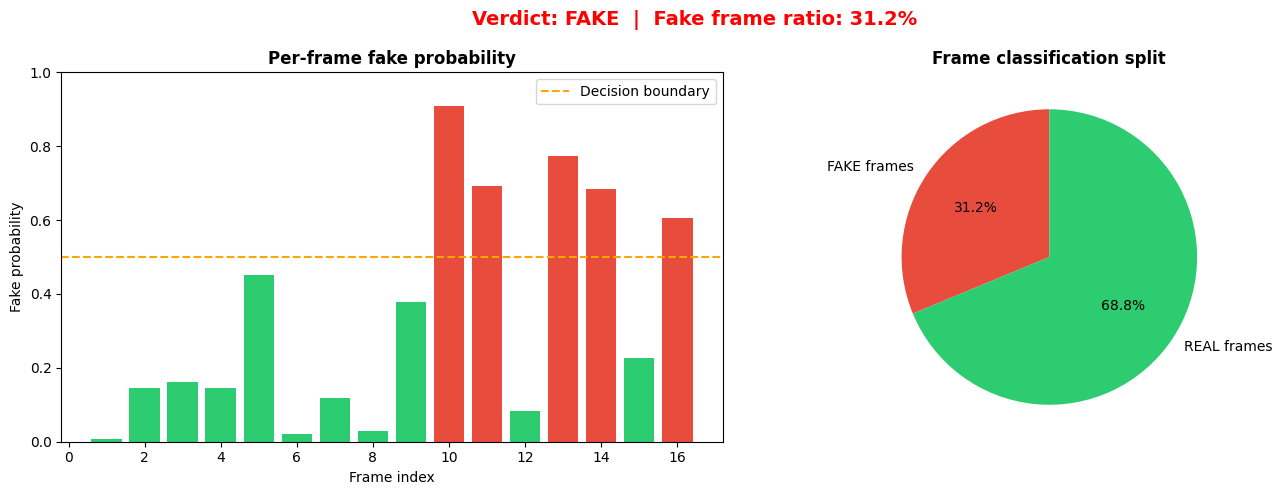


[STEP 21] FINAL VERDICT: FAKE
[STEP 21]   Fake frame ratio : 31.2% (threshold: 40%)


In [72]:
print("[STEP 21] Upload your own video for deepfake detection...")
from google.colab import files

uploaded = files.upload()
uploaded_path = list(uploaded.keys())[0]
print(f"[STEP 21] Uploaded: {uploaded_path}")

label, confidence, details = predict_video(
    uploaded_path, model, eval_transform, device,
    frame_count=16, fake_threshold=0.30, return_details=True
)

# Visualization
color = 'red' if label == 'FAKE' else 'green'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Verdict: {label}  |  Fake frame ratio: {confidence*100:.1f}%',
             fontsize=14, fontweight='bold', color=color)

# Per-frame bar chart
frames     = range(1, len(details['fake_probs']) + 1)
bar_colors = ['#e74c3c' if p > 0.5 else '#2ecc71' for p in details['fake_probs']]
axes[0].bar(frames, details['fake_probs'], color=bar_colors)
axes[0].axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[0].set_xlabel('Frame index'); axes[0].set_ylabel('Fake probability')
axes[0].set_title('Per-frame fake probability', fontweight='bold')
axes[0].set_ylim(0, 1); axes[0].legend()

# Pie chart
fake_n = sum(1 for p in details['fake_probs'] if p > 0.5)
real_n = len(details['fake_probs']) - fake_n
axes[1].pie([fake_n, real_n], labels=['FAKE frames', 'REAL frames'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Frame classification split', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\n[STEP 21] FINAL VERDICT: {label}")
print(f"[STEP 21]   Fake frame ratio : {confidence*100:.1f}% (threshold: 30%)")